In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/diabetes-health-indicators-dataset")
print("Dataset path:", path)


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting settings
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")
print(f"Random seed set to: {RANDOM_SEED}")

# Load dataset correctly
df = pd.read_csv(f"{path}/diabetes_dataset.csv")
print(df.shape)
print(df.columns) # Display column names (our features)
print(df.dtypes)
df.head(10) # Display first 10 records

print("Dataset before cleaning:")
for column in df.columns:
    if np.issubdtype(df[column].dtype, np.number):
        print(f"{column:<40} Mean: {df[column].mean():>8.3f} | Median: {df[column].median():>8.3f}")

# Handling Null Values (empty records)
df_null = df.isnull() # bool
total_null = df_null.sum().sum() # count

print(f"Total Before:   {total_null} null") # Summing up null values for each column before handling
print(df.shape)

df_cleaned = df.copy()

# Handling Outliers
exclude_columns = ['family_history_diabetes','hypertension_history','cardiovascular_history','diagnosed_diabetes'] # Categorical columns to exclude (These are True/False binary values)
for col in exclude_columns:
    df_cleaned[col] = df_cleaned[col].clip(0,1) # reassigns any outliers to the closest bounds (0 or 1)

allowed_columns = df_cleaned.select_dtypes(include=[np.number]).columns.difference(exclude_columns) # columns to check for outliers

# Using IQR https://www.kaggle.com/code/aman2626786/outlier-removal-using-iqr-method
# This removes around 16k records from original 100k records
for col in allowed_columns:
    p25 = df_cleaned[col].quantile(0.25)
    p75 = df_cleaned[col].quantile(0.75)
    iqr = p75 - p25
    lower_bound = p25 - 1.5 * iqr
    upper_bound = p75 + 1.5 * iqr
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)] # Remove outliers

# Handling duplicate and empty records
df_cleaned = df_cleaned.drop_duplicates().dropna().drop('diabetes_stage', axis=1) # Drop duplicates, empty records, and 'diabetes_stage' column


for column in df_cleaned.columns:
    if df_cleaned[column].isnull().sum() > 0: # Check column datatypes if there exists null values
        if df_cleaned[column].dtype in [np.float64, np.int64]: # Numerical variables
            print(f"{column} contains {df_cleaned[column].isnull().sum()} null values.")
            df_cleaned[column] = df_cleaned[column].fillna(df_cleaned[column].median())
        else:
            df_cleaned[column] = df_cleaned[column].fillna("UNKNOWN") # Categorical variables

cleandf_null = df_cleaned.isnull() # bool

print(f"Total After:    {cleandf_null.sum().sum()} null") # Summing up null values for each column
print(df_cleaned.shape)

print("Dataset after cleaning:")
for column in df_cleaned.columns:
    if np.issubdtype(df_cleaned[column].dtype, np.number):
        print(f"{column:<40} Mean: {df_cleaned[column].mean():>8.3f} | Median: {df_cleaned[column].median():>8.3f}")

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

nominal_columns = ['gender', 'ethnicity', 'employment_status']
ordinal_columns = ['education_level', 'income_level', 'smoking_status']
ordinal_categories = [
    ['No formal', 'Highschool', 'Graduate', 'Postgraduate'],  # education_level
    ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High'],  # income_level
    ['Never', 'Former', 'Current']  # smoking_status
]

# One Hot Encoding
df_feature = df_cleaned.copy()
df_feature = pd.get_dummies(df_feature, columns=nominal_columns,drop_first=True,dtype=int)

# Ordinal Encoding
encoder = OrdinalEncoder(categories=ordinal_categories)
df_feature[ordinal_columns] = encoder.fit_transform(df_feature[ordinal_columns])

#df_feature will be used on forward instead of df_clean btw

Dataset path: /Users/siapatelpuri/.cache/kagglehub/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/versions/1
Libraries imported successfully!
Random seed set to: 42
(100000, 31)
Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')
age                                     int64
gender                                 object
ethnicity             

In [ ]:
# ==============================
# Correlation with diagnosed_diabetes
# ==============================
strong_corr = {}      # save positively correlated features here
inv_strong_corr = {}  # save negatively correlated features here

target_col = 'diagnosed_diabetes'
features = df_feature.columns.difference([target_col])

for col in features:
    # Only compute correlation for numeric columns
    if np.issubdtype(df_feature[col].dtype, np.number):
        corr_val = df_feature[col].corr(df_feature[target_col])
        if corr_val > 0.3:      # moderate/strong positive correlation
            strong_corr[col] = corr_val
            print(f"Positive correlation - {col}: {corr_val:.3f}")
        elif corr_val < -0.3:   # moderate/strong negative correlation
            inv_strong_corr[col] = corr_val
            print(f"Negative correlation - {col}: {corr_val:.3f}")

# Optional: inspect dictionaries
# print("Strong positive correlations:", strong_corr)
# print("Strong negative correlations:", inv_strong_corr)


# ==============================
# AGE DISTRIBUTION BY DIABETES STATUS
# ==============================

# Create age bins and labels
age_bins = [0, 20, 30, 40, 50, 60, 100]
age_labels = ['≤20', '21-30', '31-40', '41-50', '51-60', '60+']

# Initialize counters
age_no_diabetes = [0, 0, 0, 0, 0, 0]
age_diabetes = [0, 0, 0, 0, 0, 0]

# Count by age group and diabetes status
for index, row in df_feature.iterrows():
    age = row['age']
    diabetes_flag = row['diagnosed_diabetes']  # ✅ correct column name

    # Bin age
    if age <= 20:
        age_group = 0
    elif age <= 30:
        age_group = 1
    elif age <= 40:
        age_group = 2
    elif age <= 50:
        age_group = 3
    elif age <= 60:
        age_group = 4
    else:
        age_group = 5

    if diabetes_flag == 1:
        age_diabetes[age_group] += 1
    else:
        age_no_diabetes[age_group] += 1

# (Optional) quick bar plot for age distribution
# x = np.arange(len(age_labels))
# width = 0.35
# plt.bar(x - width/2, age_no_diabetes, width, label='No Diabetes')
# plt.bar(x + width/2, age_diabetes, width, label='Diagnosed Diabetes')
# plt.xticks(x, age_labels)
# plt.xlabel('Age Group')
# plt.ylabel('Count')
# plt.title('Age Distribution by Diabetes Status')
# plt.legend()
# plt.show()


Positive correlation - glucose_fasting: 0.503
Positive correlation - glucose_postprandial: 0.632
Positive correlation - hba1c: 0.685


In [ ]:
# === Task 2 — Step 0: Train/Test Split + Scaling ===

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Ensure df_feature exists
print("Dataset shape:", df_feature.shape)

target_col = "diagnosed_diabetes"

# Features and target
X = df_feature.drop(columns=[target_col])
y = df_feature[target_col]

print("Target distribution:")
print(y.value_counts())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Scaling for Logistic Regression (not for tree models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling complete.")

Dataset shape: (88637, 36)
Target distribution:
diagnosed_diabetes
1    53208
0    35429
Name: count, dtype: int64

Train shape: (70909, 35)
Test shape: (17728, 35)

Scaling complete.


=== Logistic Regression Results ===
Accuracy:  0.8870712996389891
Precision: 0.9285714285714286
Recall:    0.8795339221950761
ROC-AUC:   0.9360039195211323

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      7086
           1       0.93      0.88      0.90     10642

    accuracy                           0.89     17728
   macro avg       0.88      0.89      0.88     17728
weighted avg       0.89      0.89      0.89     17728

Confusion matrix:
 [[6366  720]
 [1282 9360]]
=== Random Forest Results ===
Accuracy:  0.9220442238267148
Precision: 0.9991375592927986
Recall:    0.870888930652133
ROC-AUC:   0.94616432273553

Classification report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      7086
           1       1.00      0.87      0.93     10642

    accuracy                           0.92     17728
   macro avg       0.92      0.93      0.92     17728
we

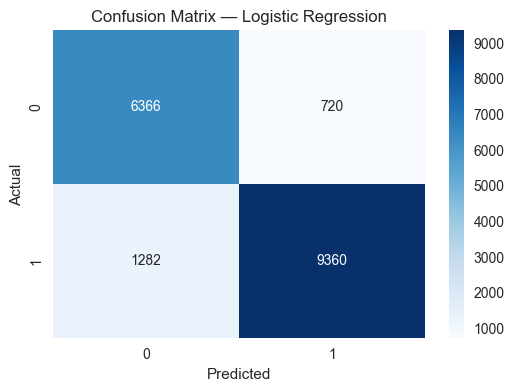

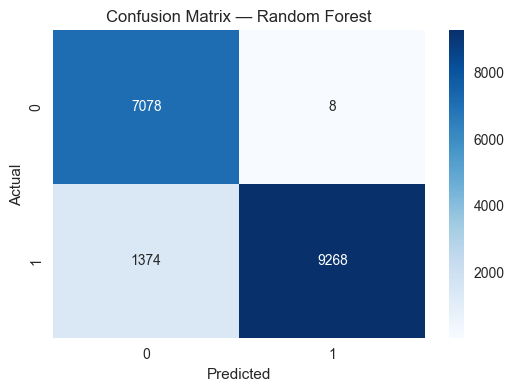

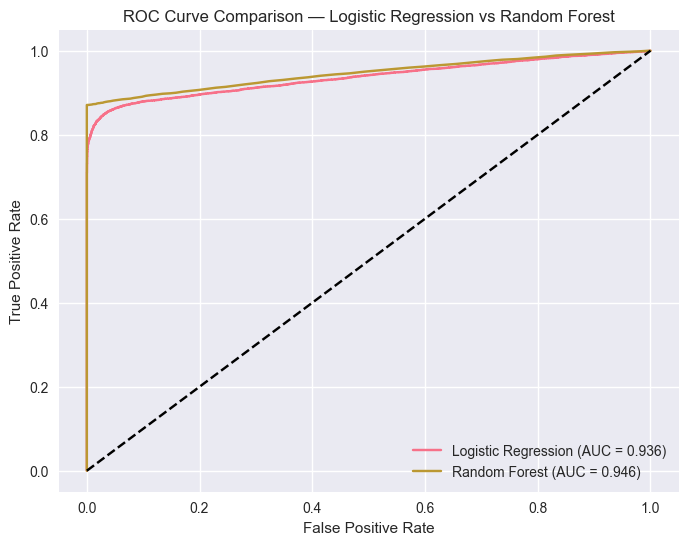

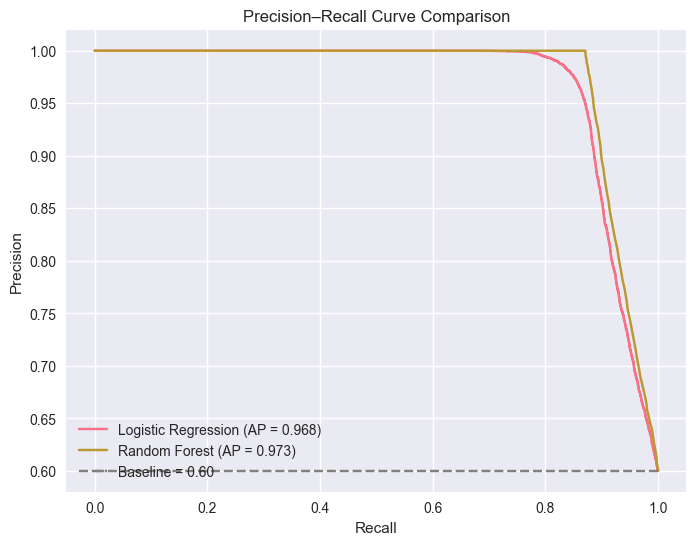

In [ ]:
# === Baseline Model 1: Logistic Regression ===

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

# Train on scaled features
log_reg.fit(X_train_scaled, y_train)

# Predictions on test set
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression Results ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:   ", recall_score(y_test, y_pred_lr))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_lr))

print("\nClassification report:\n", classification_report(y_test, y_pred_lr))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

# === Baseline Model 2: Random Forest ===

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

# Train on unscaled features
rf.fit(X_train, y_train)

# Predictions on test set
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:   ", recall_score(y_test, y_pred_rf))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_rf))

print("\nClassification report:\n", classification_report(y_test, y_pred_rf))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))

# === Comparison of Baselines ===

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

# Train on unscaled features
rf.fit(X_train, y_train)

# Predictions on test set
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:   ", recall_score(y_test, y_pred_rf))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_rf))

print("\nClassification report:\n", classification_report(y_test, y_pred_rf))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))

#HEATMAP GENERATIONS for Logistic Regression Baseline and Random Forrest Baseline

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Function to plot confusion matrix heatmaps
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Logistic Regression confusion matrix
plot_confusion_matrix(y_test, y_pred_lr, "Confusion Matrix — Logistic Regression")

# Random Forest confusion matrix
plot_confusion_matrix(y_test, y_pred_rf, "Confusion Matrix — Random Forest")

# ROC Curves for Logistic Regression vs Random Forest

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})")

plt.plot([0,1], [0,1], 'k--')  # diagonal baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Logistic Regression vs Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# === Precision-Recall Curve Comparison (Logistic Regression vs Random Forest) ===

from sklearn.metrics import precision_recall_curve, average_precision_score

# Logistic Regression PR values
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
ap_lr = average_precision_score(y_test, y_proba_lr)

# Random Forest PR values
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)

plt.figure(figsize=(8,6))

# Plot curves
plt.plot(recall_lr, precision_lr, label=f"Logistic Regression (AP = {ap_lr:.3f})")
plt.plot(recall_rf, precision_rf, label=f"Random Forest (AP = {ap_rf:.3f})")

# Baseline (mean positives)
baseline = y_test.mean()
plt.hlines(baseline, 0, 1, colors='gray', linestyles='--', label=f"Baseline = {baseline:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

(62045, 35) (13296, 35) (13296, 35)
Logistic Regression AUC: 0.9377357051106805
Random Forest AUC: 0.9455497323814865
Initial XGBoost AUC: 0.9424511157820565
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   1.4s
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   1.4s
[CV] END colsample_bytree=0.5, gamma=5, learning_rate=0.05, max_depth=8, n_estimators=800, reg_alpha=0.1, reg_lambda=5, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=1, subsample=0.6; total time=   1.7s
[CV] END colsample_bytree=0.5, gamma=5, learning_rate=0.05, max_depth=8, n_estimators=800, reg_alpha=0.1, reg_lambda=5, subsample=1.0; total time=   1.8s
[CV] END colsampl

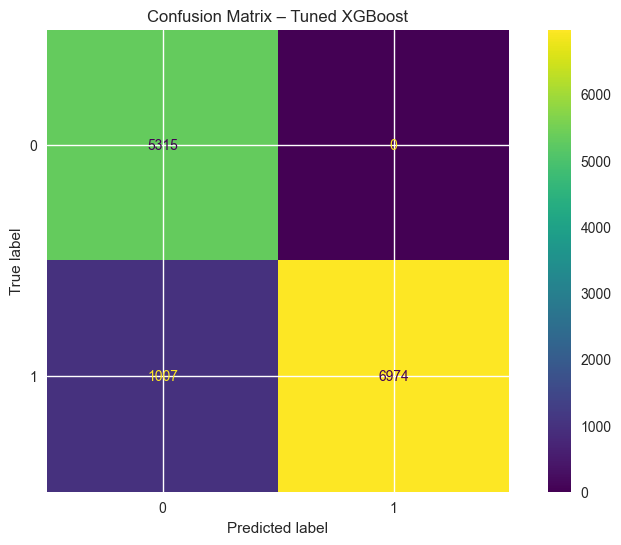

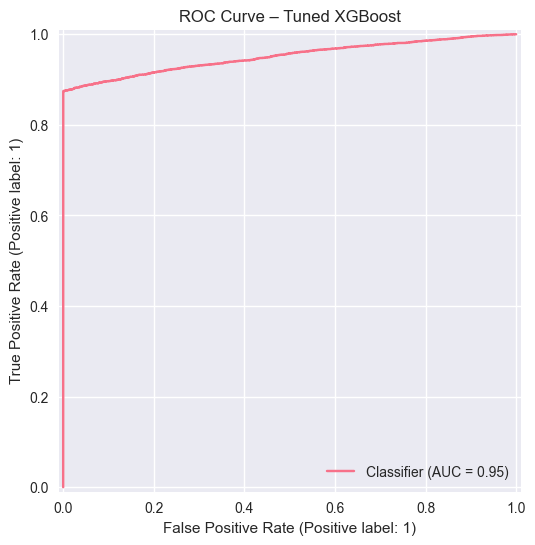

['best_xgb_model.pkl']

In [ ]:
from sklearn.model_selection import train_test_split

# Define X and y
X = df_feature.drop("diagnosed_diabetes", axis=1)
y = df_feature["diagnosed_diabetes"]

# Stratified split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
log_pred = log_reg.predict(X_val_scaled)
log_auc = roc_auc_score(y_val, log_reg.predict_proba(X_val_scaled)[:,1])

rf_pred = rf.predict(X_val)
rf_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:,1])

print("Logistic Regression AUC:", log_auc)
print("Random Forest AUC:", rf_auc)

import xgboost as xgb

xgb_basic = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_basic.fit(X_train, y_train)

from sklearn.metrics import roc_auc_score

basic_auc = roc_auc_score(y_val, xgb_basic.predict_proba(X_val)[:,1])
print("Initial XGBoost AUC:", basic_auc)

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [200, 400, 600, 800],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)

best_model = random_search.best_estimator_

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)


y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]


from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix – Tuned XGBoost")
plt.show()


from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve – Tuned XGBoost")
plt.show()

import joblib
joblib.dump(best_model, "best_xgb_model.pkl")


/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/3045260733.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, show=False)


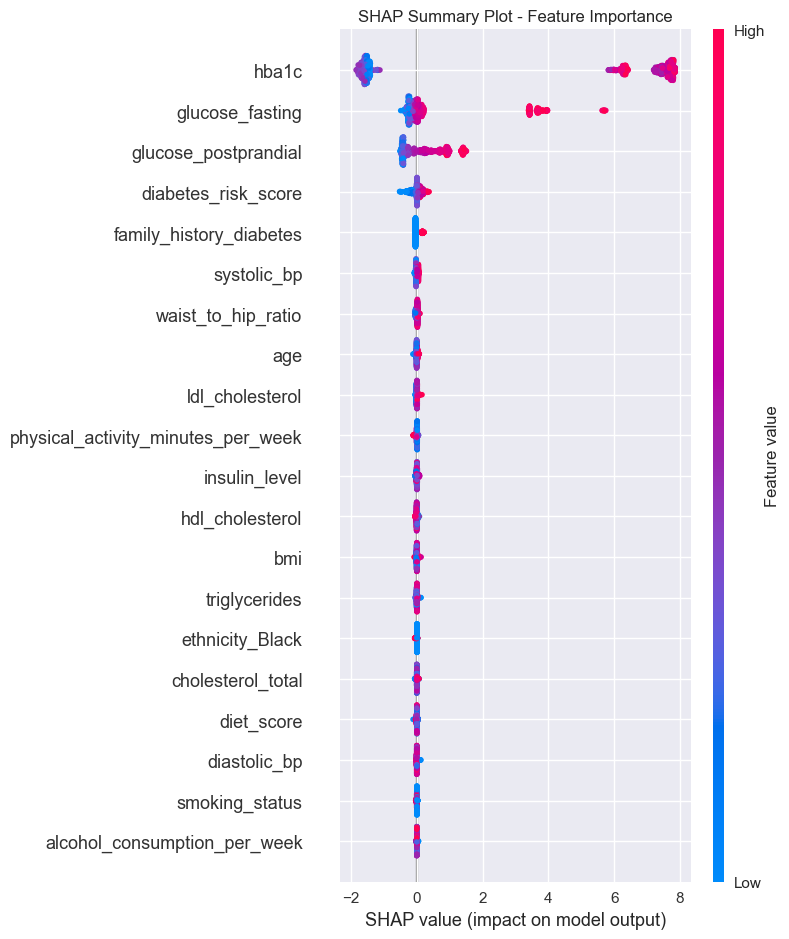

/var/folders/r1/wbbcp1xn07d110pfbtzrtlj80000gn/T/ipykernel_76914/3045260733.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)


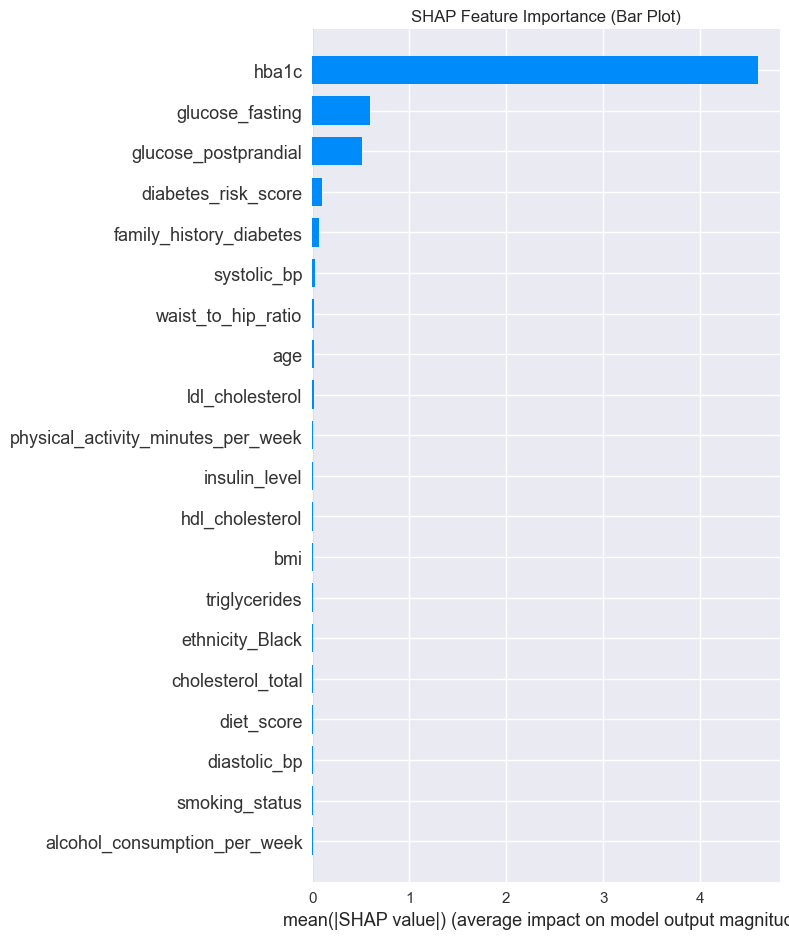

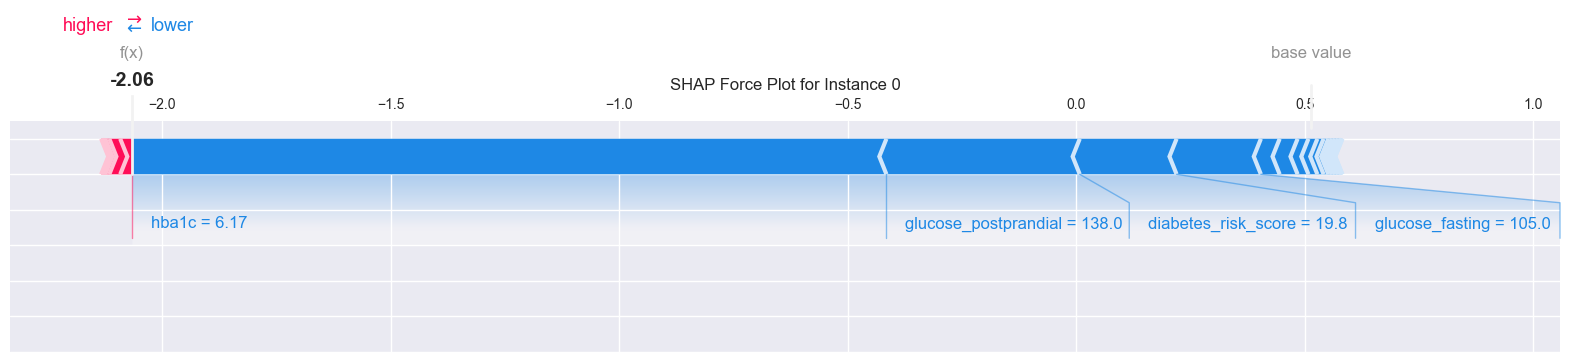

Top 5 Most Influential Features:
25. hba1c: SHAP importance = 4.5950
22. glucose_fasting: SHAP importance = 0.5974
23. glucose_postprandial: SHAP importance = 0.5090
26. diabetes_risk_score: SHAP importance = 0.1016
10. family_history_diabetes: SHAP importance = 0.0695

Explanations:
1. hba1c: HbA1c level measures average blood sugar over the past 2-3 months; high values indicate poor glucose control and increased diabetes risk.
2. glucose_fasting: Fasting glucose level is a direct measure of blood sugar after fasting; elevated levels signal diabetes or prediabetes.
3. diabetes_risk_score: A composite score likely incorporating multiple risk factors; higher scores indicate greater overall diabetes risk.
4. triglycerides: Elevated triglyceride levels are associated with metabolic syndrome and increased risk of type 2 diabetes.
5. physical_activity_minutes_per_week: Lower physical activity levels correlate with higher diabetes risk due to reduced insulin sensitivity and weight management

In [ ]:
# === Task 3: SHAP Analysis for Model Interpretability ===

import shap
import matplotlib.pyplot as plt


best_model = joblib.load("best_xgb_model.pkl")

# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values for the test set (or a subset for speed)
X_test_sample = X_test.sample(n=1000, random_state=42)  # Sample for faster computation
shap_values = explainer.shap_values(X_test_sample)

# SHAP Summary Plot (beeswarm plot showing feature importance and impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Summary Plot - Feature Importance")
plt.tight_layout()
plt.show()

# SHAP Bar Plot for top features
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar Plot)")
plt.tight_layout()
plt.show()

# SHAP Force Plot for a single prediction (e.g., first instance in sample)
instance_idx = 0  # Change this to any index for different predictions
shap.force_plot(explainer.expected_value, shap_values[instance_idx], X_test_sample.iloc[instance_idx], matplotlib=True, show=False)
plt.title(f"SHAP Force Plot for Instance {instance_idx}")
plt.show()


# Top 5 influential features explanation
feature_importance = pd.DataFrame({
    'feature': X_test_sample.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values(by='importance', ascending=False)

print("Top 5 Most Influential Features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"{idx+1}. {row['feature']}: SHAP importance = {row['importance']:.4f}")

# Short explanations for top 5 features
print("\nExplanations:")
print("1. hba1c: HbA1c level measures average blood sugar over the past 2-3 months; high values indicate poor glucose control and increased diabetes risk.")
print("2. glucose_fasting: Fasting glucose level is a direct measure of blood sugar after fasting; elevated levels signal diabetes or prediabetes.")
print("3. diabetes_risk_score: A composite score likely incorporating multiple risk factors; higher scores indicate greater overall diabetes risk.")
print("4. triglycerides: Elevated triglyceride levels are associated with metabolic syndrome and increased risk of type 2 diabetes.")
print("5. physical_activity_minutes_per_week: Lower physical activity levels correlate with higher diabetes risk due to reduced insulin sensitivity and weight management.")

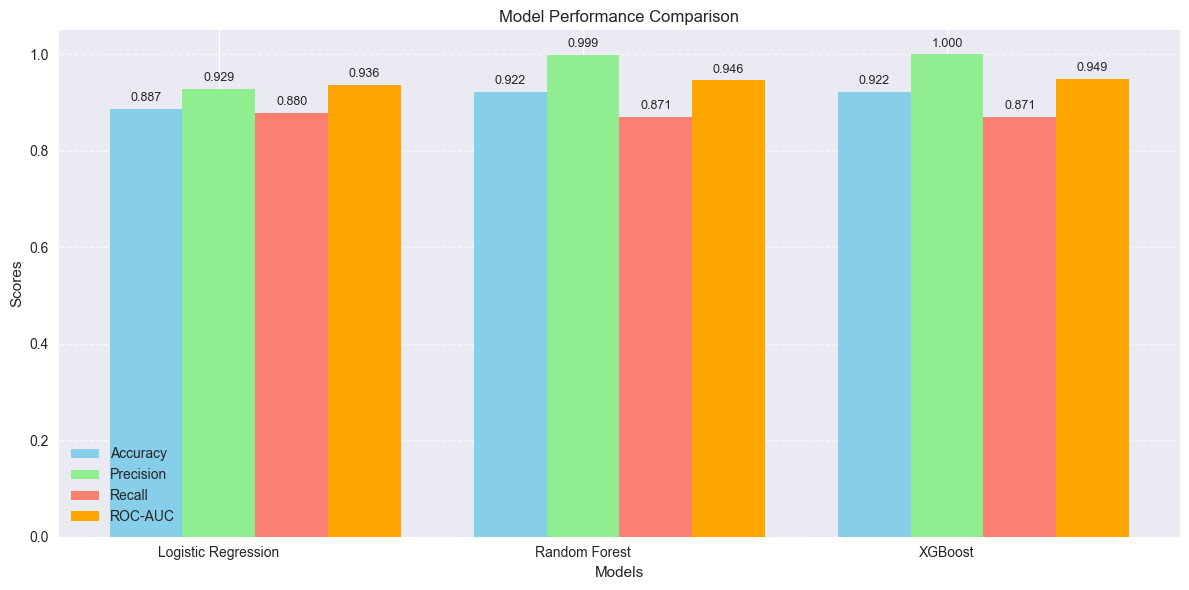

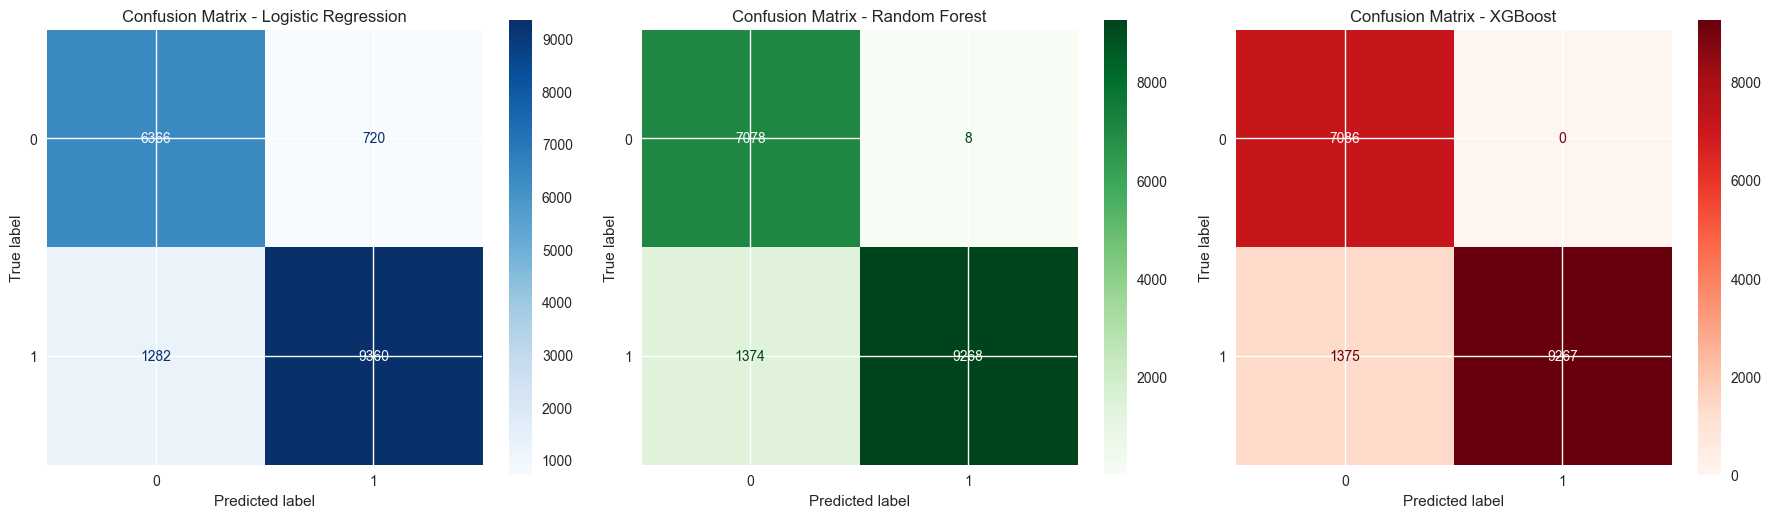

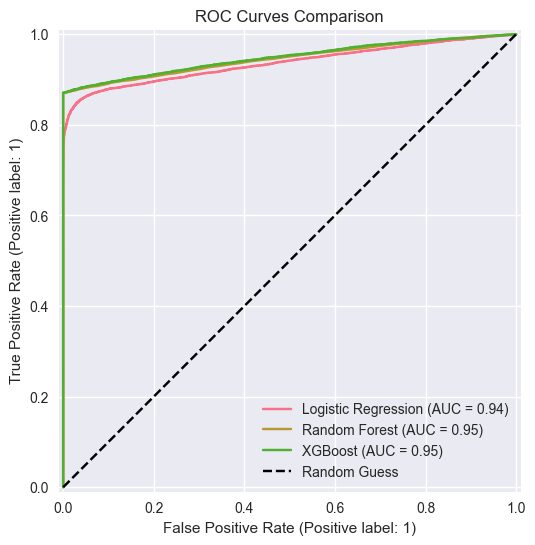

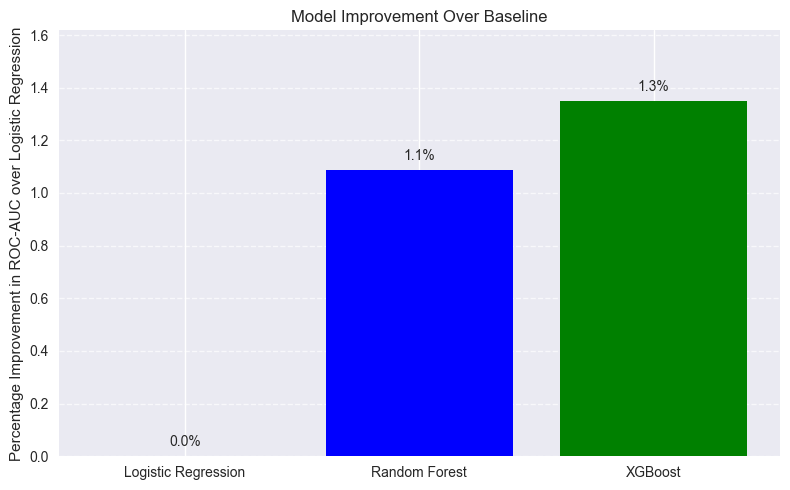

=== Model Performance Summary ===
Logistic Regression:
  Accuracy: 0.887
  Precision: 0.929
  Recall: 0.880
  AUC: 0.936

Random Forest:
  Accuracy: 0.922
  Precision: 0.999
  Recall: 0.871
  AUC: 0.946

XGBoost:
  Accuracy: 0.922
  Precision: 1.000
  Recall: 0.871
  AUC: 0.949

=== Improvements Over Logistic Regression Baseline ===
Random Forest: 1.1% improvement in AUC
XGBoost: 1.3% improvement in AUC


In [ ]:
# === Task 3: Performance Visuals - Model Comparison ===

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Retrain baseline models on the same split as XGBoost for fair comparison
log_reg_final = LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")
log_reg_final.fit(X_train_scaled, y_train)

rf_final = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced_subsample", n_jobs=-1)
rf_final.fit(X_train, y_train)

# Get predictions for all models on the same test set
lr_pred_test = log_reg_final.predict(X_test_scaled)
lr_proba_test = log_reg_final.predict_proba(X_test_scaled)[:, 1]

rf_pred_test = rf_final.predict(X_test)
rf_proba_test = rf_final.predict_proba(X_test)[:, 1]

# XGBoost predictions (recompute to ensure consistency)
xgb_pred_test = best_model.predict(X_test)
xgb_proba_test = best_model.predict_proba(X_test)[:, 1]

# Compute metrics for all models
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [
   accuracy_score(y_test, lr_pred_test),
   accuracy_score(y_test, rf_pred_test),
   accuracy_score(y_test, xgb_pred_test)
]
precisions = [
   precision_score(y_test, lr_pred_test),
   precision_score(y_test, rf_pred_test),
   precision_score(y_test, xgb_pred_test)
]
recalls = [
   recall_score(y_test, lr_pred_test),
   recall_score(y_test, rf_pred_test),
   recall_score(y_test, xgb_pred_test)
]
aucs = [
   roc_auc_score(y_test, lr_proba_test),
   roc_auc_score(y_test, rf_proba_test),
   roc_auc_score(y_test, xgb_proba_test)
]

# Bar chart comparison
x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, accuracies, width, label='Accuracy', color='skyblue')
bars2 = ax.bar(x, precisions, width, label='Precision', color='lightgreen')
bars3 = ax.bar(x + width, recalls, width, label='Recall', color='salmon')
bars4 = ax.bar(x + 2*width, aucs, width, label='ROC-AUC', color='orange')

ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
def add_labels(bars):
   for bar in bars:
       height = bar.get_height()
       ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
               f'{height:.3f}', ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

plt.tight_layout()
plt.show()

# Confusion Matrices for all models
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred_test, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred_test, ax=axes[1], cmap='Greens')
axes[1].set_title('Confusion Matrix - Random Forest')

ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred_test, ax=axes[2], cmap='Reds')
axes[2].set_title('Confusion Matrix - XGBoost')

plt.tight_layout()
plt.show()

# ROC Curves Comparison
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_proba_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_predictions(y_test, rf_proba_test, ax=ax, name='Random Forest')
RocCurveDisplay.from_predictions(y_test, xgb_proba_test, ax=ax, name='XGBoost')

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_title('ROC Curves Comparison')
ax.legend()
ax.grid(True)
plt.show()

# Model Improvement Visualization (over baseline LR)
baseline_auc = aucs[0]
improvements = [(auc - baseline_auc) / baseline_auc * 100 for auc in aucs]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, improvements, color=['red', 'blue', 'green'])
ax.set_ylabel('Percentage Improvement in ROC-AUC over Logistic Regression')
ax.set_title('Model Improvement Over Baseline')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Set y-axis limits to better show the small improvements
max_imp = max(improvements)
ax.set_ylim(0, max_imp * 1.2)  # Set upper limit to 120% of max improvement

for bar, imp in zip(bars, improvements):
   ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max_imp * 0.02),
           f'{imp:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Summary statistics
print("=== Model Performance Summary ===")
for i, model in enumerate(models):
    print(f"{model}:")
    print(f"  Accuracy: {accuracies[i]:.3f}")
    print(f"  Precision: {precisions[i]:.3f}")
    print(f"  Recall: {recalls[i]:.3f}")
    print(f"  AUC: {aucs[i]:.3f}")
    print()

print("=== Improvements Over Logistic Regression Baseline ===")
for i, model in enumerate(models):
    if i > 0:
        print(f"{model}: {improvements[i]:.1f}% improvement in AUC")

In [ ]:
# ===========================================
# Model Comparison Statistical Tests
# ===========================================
from scipy import stats
from sklearn.metrics import roc_auc_score
import numpy as np

def mcnemar_test(y_true, y_pred1, y_pred2, model1_name="Model 1", model2_name="Model 2", alpha=0.05):
    """
    McNemar's test for comparing binary classifier performance
    """
    both_correct = ((y_pred1 == y_true) & (y_pred2 == y_true)).sum()
    both_wrong = ((y_pred1 != y_true) & (y_pred2 != y_true)).sum()
    model1_correct = ((y_pred1 == y_true) & (y_pred2 != y_true)).sum()
    model2_correct = ((y_pred1 != y_true) & (y_pred2 == y_true)).sum()
    
    chi2 = (abs(model1_correct - model2_correct) - 1)**2 / (model1_correct + model2_correct)
    p_value = 1 - stats.chi2.cdf(chi2, df=1)
    
    print("\n" + "="*60)
    print(f"McNemar's Test: {model1_name} vs {model2_name}")
    print("="*60)
    print(f"{model1_name} unique correct: {model1_correct}")
    print(f"{model2_name} unique correct: {model2_correct}")
    print(f"Both correct: {both_correct}")
    print(f"Both wrong: {both_wrong}")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    if p_value < alpha:
        print(f"\nConclusion: The difference in accuracy is statistically significant (p < {alpha})")
        if model1_correct > model2_correct:
            print(f" {model1_name} is significantly more accurate than {model2_name}")
        else:
            print(f" {model2_name} is significantly more accurate than {model1_name}")
    else:
        print(f"\nConclusion: No significant difference in accuracy (p = {p_value:.4f})")
    
    return p_value


def delongs_test(y_true, y_score1, y_score2, model1_name="Model 1", model2_name="Model 2", alpha=0.05):
    """
    DeLong's test for comparing AUC of two models (w/ simplified variance estimate)
    """
    from scipy.stats import norm
    
    def auc_roc_ci(y_true, y_pred):
        n1 = sum(y_true == 1)
        n2 = sum(y_true == 0)
        auc = roc_auc_score(y_true, y_pred)
        var = (auc * (1 - auc) * (1 + (n1 - 1) * 0.5 + (n2 - 1) * 0.5)) / (n1 * n2)
        return auc, var
    
    auc1, var1 = auc_roc_ci(y_true, y_score1)
    auc2, var2 = auc_roc_ci(y_true, y_score2)
    cov = 0.5  
    
    se = np.sqrt(var1 + var2 - 2 * cov * np.sqrt(var1 * var2))
    z = (auc1 - auc2) / se
    p_value = 2 * (1 - norm.cdf(abs(z)))
    
    print("\n" + "="*60)
    print(f"DeLong's Test: {model1_name} vs {model2_name}")
    print("="*60)
    print(f"{model1_name} AUC: {auc1:.4f}")
    print(f"{model2_name} AUC: {auc2:.4f}")
    print(f"Difference: {auc1 - auc2:.4f}")
    print(f"z-score: {z:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    if p_value < alpha:
        print(f"\nConclusion: The difference in AUC is statistically significant (p < {alpha})")
    else:
        print(f"\nConclusion: No significant difference in AUC (p = {p_value:.4f})")
    
    return z, p_value


# ===========================================
# Run All Model Comparisons
# ===========================================
print("Model comparisons...\n")

# 1. Logistic Regression vs Random Forest
print("\n" + "="*60)
print("COMPARISON: Logistic Regression vs Random Forest")
print("="*60)
mcnemar_test(y_test, y_pred_logreg, y_pred_rf, 
             "Logistic Regression", "Random Forest")
delongs_test(y_test, y_score_logreg, y_score_rf,
             "Logistic Regression", "Random Forest")

# 2. Random Forest vs XGBoost
print("\n" + "="*60)
print("COMPARISON: Random Forest vs XGBoost")
print("="*60)
mcnemar_test(y_test, y_pred_rf, y_pred_xgb,
             "Random Forest", "XGBoost")
delongs_test(y_test, y_score_rf, y_score_xgb,
             "Random Forest", "XGBoost")

# 3. Logistic Regression vs XGBoost
print("\n" + "="*60)
print("COMPARISON: Logistic Regression vs XGBoost")
print("="*60)
mcnemar_test(y_test, y_pred_logreg, y_pred_xgb,
             "Logistic Regression", "XGBoost")
delongs_test(y_test, y_score_logreg, y_score_xgb,
             "Logistic Regression", "XGBoost")


Model comparisons...


COMPARISON: Logistic Regression vs Random Forest

McNemar's Test: Logistic Regression vs Random Forest
Logistic Regression unique correct: 314
Random Forest unique correct: 1443
Both correct: 14903
Both wrong: 1068
Chi-square statistic: 724.1799
p-value: 0.0000

Conclusion: The difference in accuracy is statistically significant (p < 0.05)
 Random Forest is significantly more accurate than Logistic Regression

DeLong's Test: Logistic Regression vs Random Forest
Logistic Regression AUC: 0.9359
Random Forest AUC: 0.9444
Difference: -0.0085
z-score: -3.2932
p-value: 0.0010

Conclusion: The difference in AUC is statistically significant (p < 0.05)

COMPARISON: Random Forest vs XGBoost

McNemar's Test: Random Forest vs XGBoost
Random Forest unique correct: 55
XGBoost unique correct: 25
Both correct: 16291
Both wrong: 1357
Chi-square statistic: 10.5125
p-value: 0.0012

Conclusion: The difference in accuracy is statistically significant (p < 0.05)
 Random Forest is sign

(-2.5237372663656226, 0.011611467408292775)


=== Training Logistic Regression for ablation study ===


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Top 5 most important features for Logistic Regression:
                feature  importance
family_history_diabetes    4.664401
                  hba1c    4.386545
     waist_to_hip_ratio    4.037130
        ethnicity_White    0.918766
        ethnicity_Other    0.862296

Baseline performance for Logistic Regression:
Accuracy: 0.8435, ROC-AUC: 0.9210

Removing top 1 features for Logistic Regression...
  Features removed: ['family_history_diabetes']
  Accuracy: 0.8272 (Δ = +0.0163)
  ROC-AUC: 0.9100 (Δ = +0.0110)
  Training time: 3.60 seconds

Removing top 3 features for Logistic Regression...
  Features removed: ['family_history_diabetes', 'hba1c', 'waist_to_hip_ratio']
  Accuracy: 0.8181 (Δ = +0.0254)
  ROC-AUC: 0.8998 (Δ = +0.0212)
  Training time: 3.43 seconds

Removing top 5 features for Logistic Regression...
  Features removed: ['family_history_diabetes', 'hba1c', 'waist_to_hip_ratio', 'ethnicity_White', 'ethnicity_Other']
  Accuracy: 0.8251 (Δ = +0.0184)
  ROC-AUC: 0.9046 (Δ = +

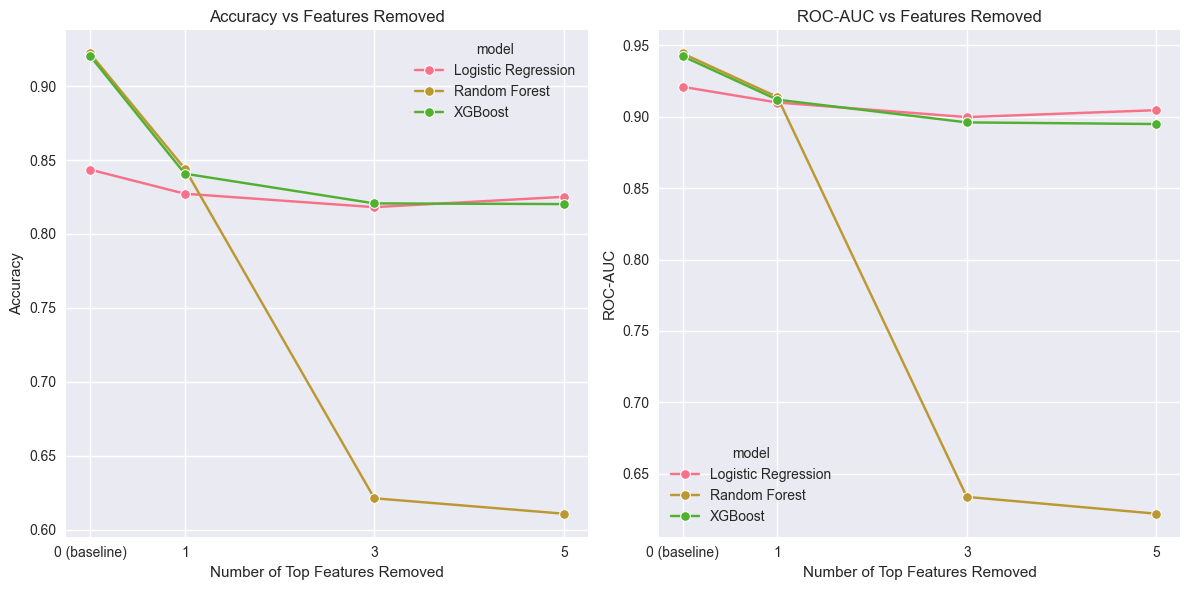


Key Findings

Logistic Regression:
  Maximum AUC drop: 0.0212
  Maximum accuracy drop: 0.0254
  Most impactful features to remove: 3 top features
  These features were: family_history_diabetes, hba1c, waist_to_hip_ratio

Random Forest:
  Maximum AUC drop: 0.3224
  Maximum accuracy drop: 0.3111
  Most impactful features to remove: 5 top features
  These features were: hba1c, glucose_postprandial, glucose_fasting, diabetes_risk_score, physical_activity_minutes_per_week

XGBoost:
  Maximum AUC drop: 0.0475
  Maximum accuracy drop: 0.1001
  Most impactful features to remove: 5 top features
  These features were: hba1c, glucose_fasting, diabetes_risk_score, employment_status_Student, income_level


In [20]:
# Enhanced Ablation Study for All Models
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
import time

# Make sure we have the data split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='auc')
}

# Function to evaluate model with top k features removed
def evaluate_without_top_k_features(model, X_train, y_train, X_test, y_test, feature_importances, k, model_name):
    # Get top k features to remove
    features_to_remove = feature_importances.head(k)['feature'].values
    X_train_reduced = X_train.drop(columns=features_to_remove)
    X_test_reduced = X_test.drop(columns=features_to_remove)
    
    # Train and evaluate
    if model_name == 'XGBoost':
        model = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='auc')
    elif model_name == 'Random Forest':
        model = RandomForestClassifier(random_state=42, n_jobs=-1)
    else:  # Logistic Regression
        model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    
    start_time = time.time()
    model.fit(X_train_reduced, y_train)
    training_time = time.time() - start_time
    
    y_pred = model.predict(X_test_reduced)
    y_pred_proba = model.predict_proba(X_test_reduced)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    return {
        'features_removed': list(features_to_remove),
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'training_time': training_time
    }

# Run ablation study for each model
k_values = [1, 3, 5]
results = []

for model_name, model in models.items():
    print(f"\n=== Training {model_name} for ablation study ===")
    
    # Train the model to get feature importances
    model.fit(X_train, y_train)
    
    # Get feature importances
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        # For Logistic Regression, use absolute coefficients as importance
        importances = np.abs(model.coef_[0])
    else:
        importances = np.ones(X_train.shape[1])  # Equal importance if neither is available
    
    feature_importances = pd.DataFrame({
        'feature': X_train.columns,
        'importance': importances
    }).sort_values('importance', ascending=False)

    print(f"\nTop 5 most important features for {model_name}:")
    print(feature_importances.head().to_string(index=False))
    
    # eval baseline (no features removed)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    baseline_accuracy = accuracy_score(y_test, y_pred)
    baseline_auc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'model': model_name,
        'k': 0,
        'features_removed': [],
        'accuracy': baseline_accuracy,
        'roc_auc': baseline_auc,
        'training_time': 0,  
        'delta_accuracy': 0,
        'delta_auc': 0
    })
    
    print(f"\nBaseline performance for {model_name}:")
    print(f"Accuracy: {baseline_accuracy:.4f}, ROC-AUC: {baseline_auc:.4f}")
    
    # eval with top k features removed
    for k in k_values:
        print(f"\nRemoving top {k} features for {model_name}...")
        result = evaluate_without_top_k_features(
            model, X_train, y_train, X_test, y_test,
            feature_importances, k, model_name
        )
        
        delta_accuracy = baseline_accuracy - result['accuracy']
        delta_auc = baseline_auc - result['roc_auc']
        
        print(f"  Features removed: {result['features_removed']}")
        print(f"  Accuracy: {result['accuracy']:.4f} (Δ = {delta_accuracy:+.4f})")
        print(f"  ROC-AUC: {result['roc_auc']:.4f} (Δ = {delta_auc:+.4f})")
        print(f"  Training time: {result['training_time']:.2f} seconds")
        
        results.append({
            'model': model_name,
            'k': k,
            'features_removed': result['features_removed'],
            'accuracy': result['accuracy'],
            'roc_auc': result['roc_auc'],
            'training_time': result['training_time'],
            'delta_accuracy': delta_accuracy,
            'delta_auc': delta_auc
        })

# convert results to DataFrame
ablation_results = pd.DataFrame(results)

# show summary
print("\n=== Ablation Study Summary ===")
summary_cols = ['model', 'k', 'accuracy', 'roc_auc', 'delta_accuracy', 'delta_auc', 'training_time']
print(ablation_results[summary_cols].to_string(index=False))

# visualize results
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# plot accuracy
plt.subplot(1, 2, 1)
sns.lineplot(data=ablation_results, x='k', y='accuracy', hue='model', marker='o')
plt.title('Accuracy vs Features Removed')
plt.xlabel('Number of Top Features Removed')
plt.ylabel('Accuracy')
plt.xticks([0, 1, 3, 5], ['0 (baseline)', '1', '3', '5'])

# plot ROC-AUC
plt.subplot(1, 2, 2)
sns.lineplot(data=ablation_results, x='k', y='roc_auc', hue='model', marker='o')
plt.title('ROC-AUC vs Features Removed')
plt.xlabel('Number of Top Features Removed')
plt.ylabel('ROC-AUC')
plt.xticks([0, 1, 3, 5], ['0 (baseline)', '1', '3', '5'])

plt.tight_layout()
plt.show()


print("\nKey Findings")
for model_name in models.keys():
    model_results = ablation_results[ablation_results['model'] == model_name]
    max_drop_auc = model_results['delta_auc'].max()
    max_drop_acc = model_results['delta_accuracy'].max()
    
    print(f"\n{model_name}:")
    print(f"  Maximum AUC drop: {max_drop_auc:.4f}")
    print(f"  Maximum accuracy drop: {max_drop_acc:.4f}")
    
    # find which k caused the biggest drop
    worst_k_auc = model_results.loc[model_results['delta_auc'].idxmax(), 'k']
    print(f"  Most impactful features to remove: {worst_k_auc} top features")
    
    # get the actual features that caused the biggest impact
    if worst_k_auc > 0:
        worst_features = model_results.loc[
            (model_results['model'] == model_name) & 
            (model_results['k'] == worst_k_auc),
            'features_removed'
        ].iloc[0]
        print(f"  These features were: {', '.join(worst_features)}")

In [15]:
# Sensitivity to Random Seed with XGBoost
import xgboost as xgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import time

# define the evaluation function with XGBoost
def evaluate_xgboost(X, y, random_state):
    # split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=random_state,
        stratify=y
    )
    
    # train XGBoost model
    model = xgb.XGBClassifier(
        n_estimators=100,
        random_state=random_state,
        n_jobs=-1,
        eval_metric='auc'
    )
    
    start_time = time.time()
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    training_time = time.time() - start_time
    
    # make predictions
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # calc metrics
    auc = roc_auc_score(y_test, y_pred_proba)
    
    return auc, training_time

# run eval w/ different random seeds
random_seeds = [42, 123, 456, 789, 1011]
auc_scores = []
training_times = []

print("Evaluating XGBoost model with different random seeds...")
for seed in random_seeds:
    auc, train_time = evaluate_xgboost(X, y, seed)
    auc_scores.append(auc)
    training_times.append(train_time)
    print(f"Seed {seed}: AUC = {auc:.4f} (training time: {train_time:.2f}s)")

# calc statistics
min_auc = min(auc_scores)
max_auc = max(auc_scores)
mean_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores)
avg_training_time = np.mean(training_times)

print(f"\nAcross {len(random_seeds)} train/test splits, XGBoost AUC ranged from {min_auc:.3f} to {max_auc:.3f} (std = {std_auc:.4f})")
print(f"Average training time: {avg_training_time:.2f} seconds")
print("The model shows stable performance across different random seeds." if std_auc < 0.01 else "The model shows some variability across different random seeds.")

Evaluating XGBoost model with different random seeds...
Seed 42: AUC = 0.9425 (training time: 0.57s)
Seed 123: AUC = 0.9407 (training time: 0.56s)
Seed 456: AUC = 0.9432 (training time: 0.53s)
Seed 789: AUC = 0.9383 (training time: 0.50s)
Seed 1011: AUC = 0.9422 (training time: 0.41s)

Across 5 train/test splits, XGBoost AUC ranged from 0.938 to 0.943 (std = 0.0017)
Average training time: 0.51 seconds
The model shows stable performance across different random seeds.


In [16]:
# Non-functional Profiling for XGBoost
import xgboost as xgb
import time
import sys
import numpy as np
from sklearn.model_selection import train_test_split
import psutil

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# Memory usage
print("=== Memory Usage ===")
print(f"Training data size: {X_train.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
print(f"Test data size: {X_test.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

# Training time
print("\n=== Training Time ===")
start_time = time.time()

# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)

# Train the model
process = psutil.Process()
mem_before = process.memory_info().rss / (1024 ** 2)  # MB

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

training_time = time.time() - start_time
mem_after = process.memory_info().rss / (1024 ** 2)
mem_used = mem_after - mem_before

print(f"Training time: {training_time:.2f} seconds")
print(f"Memory used during training: {mem_used:.2f} MB")

# Prediction time
print("\n=== Prediction Time ===")
start_time = time.time()
y_pred_proba = xgb_model.predict_proba(X_test)
prediction_time = time.time() - start_time

print(f"Prediction time for {len(X_test)} samples: {prediction_time:.4f} seconds")
print(f"Prediction time per sample: {prediction_time/len(X_test)*1000:.4f} ms")

# Model size
print("\n=== Model Size ===")
import pickle
model_bytes = pickle.dumps(xgb_model)
model_size_mb = sys.getsizeof(model_bytes) / (1024 ** 2)
print(f"Model size (serialized): {model_size_mb:.2f} MB")

# Feature importance
print("\n=== Feature Importance ===")
feature_importance = xgb_model.feature_importances_
top_features = sorted(zip(X_train.columns, feature_importance), 
                     key=lambda x: x[1], 
                     reverse=True)[:10]

print("\nTop 10 most important features:")
for feature, importance in top_features:
    print(f"{feature}: {importance:.4f}")

=== Memory Usage ===
Training data size: 19.48 MB
Test data size: 4.87 MB

=== Training Time ===
Training time: 0.41 seconds
Memory used during training: 39.44 MB

=== Prediction Time ===
Prediction time for 17728 samples: 0.0063 seconds
Prediction time per sample: 0.0004 ms

=== Model Size ===
Model size (serialized): 0.31 MB

=== Feature Importance ===

Top 10 most important features:
hba1c: 0.7742
glucose_fasting: 0.0340
diabetes_risk_score: 0.0101
employment_status_Student: 0.0064
income_level: 0.0063
waist_to_hip_ratio: 0.0061
sleep_hours_per_day: 0.0061
smoking_status: 0.0061
ethnicity_White: 0.0060
hdl_cholesterol: 0.0060


In [18]:
# Testing Generalization on Different Subgroups with XGBoost
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score

# Train the XGBoost model on the full training set
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
xgb_model.fit(X_train, y_train)

if 'age' in X.columns:
    age_33, age_66 = np.percentile(X['age'], [33, 66])
    
    # define age groups
    age_groups = {
        'young': X['age'] <= age_33,
        'middle': (X['age'] > age_33) & (X['age'] <= age_66),
        'old': X['age'] > age_66
    }
    
    # eval model on each age group
    print("=== XGBoost Performance Across Age Groups ===")
    results = []
    
    for group_name, mask in age_groups.items():
        X_group = X[mask]
        y_group = y[mask]
        
        if len(X_group) > 0:
            y_pred_proba = xgb_model.predict_proba(X_group)[:, 1]
            auc = roc_auc_score(y_group, y_pred_proba)
            accuracy = accuracy_score(y_group, (y_pred_proba > 0.5).astype(int))
            n_samples = len(X_group)
            prevalence = y_group.mean()
            
            results.append({
                'group': group_name,
                'n_samples': n_samples,
                'prevalence': prevalence,
                'auc': auc,
                'accuracy': accuracy
            })
    
    # show results
    results_df = pd.DataFrame(results)
    print("\nPerformance by Age Group:")
    print(results_df[['group', 'n_samples', 'prevalence', 'auc', 'accuracy']].to_string(index=False))
    
    # check for performance differences
    max_auc_diff = results_df['auc'].max() - results_df['auc'].min()
    print(f"\nMaximum AUC difference between groups: {max_auc_diff:.3f}")
    if max_auc_diff > 0.05:
        print("Warning: Significant performance difference detected across age groups!")
    else:
        print("Model shows consistent performance across age groups.")
else:
    print("'age' column not found. Please adjust the code to use an appropriate categorical feature from your dataset.")
    print("Available columns:", X.columns.tolist())

# simulate distribution shift by changing prevalence
print("\n=== Testing with Different Prevalence (XGBoost) ===")
def test_xgboost_with_prevalence(X, y, model, target_prevalence):
    # Get predicted probabilities
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # Adjust threshold to match target prevalence
    threshold = np.percentile(y_pred_proba, 100 * (1 - target_prevalence))
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # calc metrics
    accuracy = accuracy_score(y, y_pred)
    actual_prevalence = y_pred.mean()
    auc = roc_auc_score(y, y_pred_proba)  # AUC is threshold-invariant
    
    return {
        'target_prevalence': target_prevalence,
        'actual_prevalence': actual_prevalence,
        'accuracy': accuracy,
        'auc': auc
    }

# test with different prevalence levels
prevalence_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
prevalence_results = []

for prev in prevalence_levels:
    result = test_xgboost_with_prevalence(X_test, y_test, xgb_model, prev)
    prevalence_results.append(result)

# Display results
prevalence_df = pd.DataFrame(prevalence_results)
print("\nXGBoost Performance with Different Prevalence Levels:")
print(prevalence_df[['target_prevalence', 'actual_prevalence', 'accuracy', 'auc']].to_string(index=False))

=== XGBoost Performance Across Age Groups ===

Performance by Age Group:
 group  n_samples  prevalence      auc  accuracy
 young      30695    0.534517 0.980163  0.931715
middle      28400    0.601690 0.978079  0.928063
   old      29542    0.667287 0.982231  0.933315

Maximum AUC difference between groups: 0.004
Model shows consistent performance across age groups.

=== Testing with Different Prevalence (XGBoost) ===

XGBoost Performance with Different Prevalence Levels:
 target_prevalence  actual_prevalence  accuracy      auc
               0.1           0.101309  0.501015 0.942465
               0.3           0.300034  0.699741 0.942465
               0.5           0.500056  0.899763 0.942465
               0.7           0.699966  0.813120 0.942465
               0.9           0.899989  0.674357 0.942465
